# Convolutional networks in PyTorch

Andres Gonzalez Ojeda

In this activity we'll create models that classify images into ten categories using the CIFAR-10 dataset using CNNs. 

The dataset was recovered directly from torchvision datasets.

In [1]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

We load the dataset using PILToTensor as a transform to pass the images to tensor vectors. We can see what the classes are below.

In [3]:
transform = transforms.Compose([
    transforms.PILToTensor()
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

classes = train_dataset.classes
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {classes}")

c:\Users\spisi\Documents\repos\computer-inteligence\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
def show(img, lbl):
    if torch.is_tensor(img):
        img = img.permute(1, 2, 0).cpu().numpy()

    label_name = classes[int(lbl)] if isinstance(lbl, (int, float)) or str(lbl).isdigit() else lbl

    plt.figure(figsize=(4, 4))
    plt.title(label_name, fontsize=12)
    plt.axis("off")
    plt.imshow(img)

Here we can see some examples of the images with their respective labels. We can see the problem is much more complex than the ones viewed before. These images are "normal" with much more noise and undefined silhouettes.

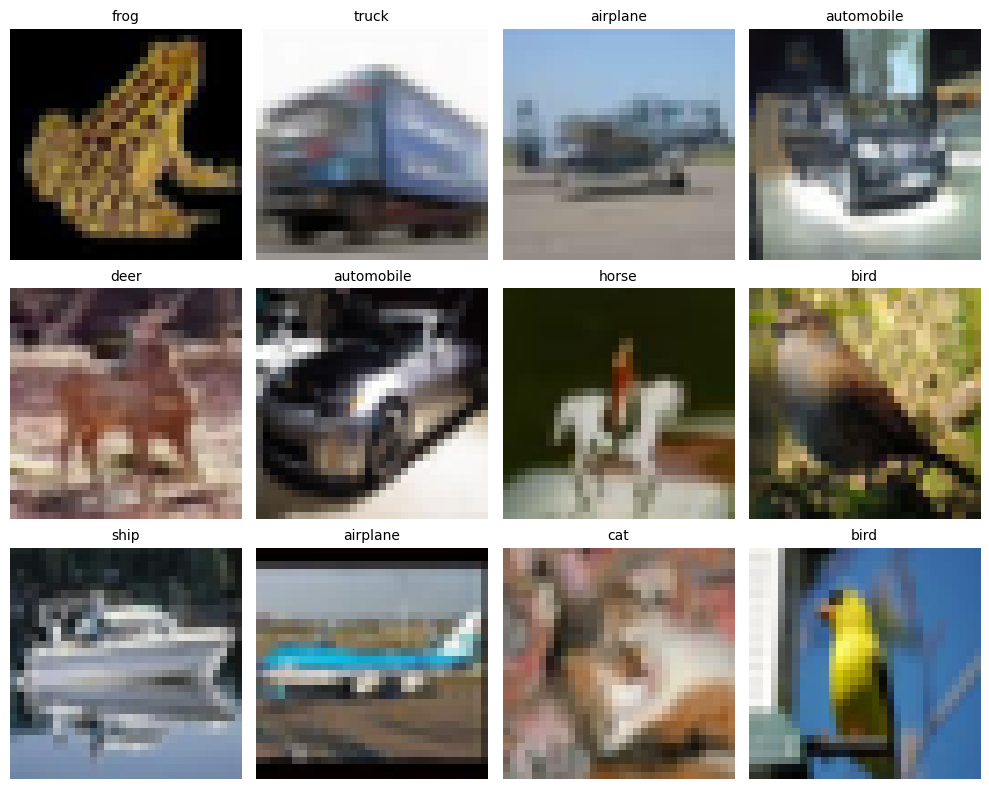

In [5]:
num_rows, num_cols = 3, 4
num_samples = num_rows * num_cols
sample_indices = random.sample(range(len(train_dataset)), num_samples)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 8))

for ax, idx in zip(axes.flatten(), sample_indices):
    image, label = train_dataset[idx]

    if torch.is_tensor(image):
        image = image.permute(1, 2, 0).cpu().numpy()

    ax.imshow(image)
    ax.set_title(classes[label], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

We create a calculate accuracy function since we're using it to evaluate the model

In [6]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

The train function does a complete training loop. For each epoch it computes predictions on the training batches and updates the weights, calculating the training loss and accuracy. Then evaluates the model with the test dataset. It stores a history dictionary with the metrics for accuracy and loss for both datasets.

In [7]:
def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs, device):
    _model.to(device)
    res = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0

        for X_batch, y_batch in _train_loader:
            X_batch = X_batch.to(device=device, dtype=torch.float32)
            y_batch = y_batch.to(device=device, dtype=torch.long)

            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)
        epoch_train_acc = train_acc

        _model.eval()
        test_loss = 0.0
        test_acc = 0.0

        with torch.no_grad():
            for X_test, y_test in _test_loader:
                X_test = X_test.to(device=device, dtype=torch.float32)
                y_test = y_test.to(device=device, dtype=torch.long)

                test_outputs = _model(X_test)
                test_loss += _criterion(test_outputs, y_test).item() * X_test.size(0)
                test_acc += get_batch_accuracy(test_outputs, y_test, len(_test_loader.dataset))

        epoch_test_loss = test_loss / len(_test_loader.dataset)
        epoch_test_acc = test_acc

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{epoch_train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{epoch_test_acc:.4f}",
        )

        res["train_loss"].append(epoch_train_loss)
        res["train_acc"].append(epoch_train_acc)
        res["test_loss"].append(epoch_test_loss)
        res["test_acc"].append(epoch_test_acc)

    return res

The training funciton calculates the average loss and accuracy across the entire train dataset.

In [8]:
IMG_CHANNELS = 3
NUM_CLASSES = 10
def test(_model, _test_loader, _loss_function, device):
    _model.to(device)
    _model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for x, y in _test_loader:
            x = x.to(device=device, dtype=torch.float32)
            y = y.to(device=device, dtype=torch.long)
            
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_correct += (output.argmax(dim=1) == y).sum().item()
            test_total += y.size(0)

    return (test_loss / test_total), (test_correct / test_total)

## Training

Here we use three CNN configurations. I left the first configuration with only two layers without dropout. Then I used the same amount of hidden layers (4) for the next two configurations. But on CNN_2 I only used dropout on one of the hidden layers and I used dropout on all the hidden layers for the last configuration. Mainly because I want to see the impact that dropout has on the results.

In [9]:
class CNN_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(25, 50, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(50, 75, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Flatten(),
            nn.Linear(75 * 4 * 4, 512),
            nn.ReLU(),
            nn.Linear(512, NUM_CLASSES),
        )

    def forward(self, x):
        return self.model(x)

In [10]:
# intermittent dropout
class CNN_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(25, 50, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(50, 75, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(75, 125, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(125, 250, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Flatten(),
            nn.Linear(250 * 1 * 1, 512),
            nn.Dropout(0.3),
            nn.ReLU(),
            nn.Linear(512, NUM_CLASSES),

            
        )

    def forward(self, x):
        return self.model(x)

In [11]:
# With dropouts
class CNN_3(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(25, 50, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(50, 75, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(75, 125, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(125, 250, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool2d(2, stride=2),

            nn.Flatten(),
            nn.Linear(250 * 1 * 1, 512),
            nn.Dropout(0.4),
            nn.ReLU(),
            nn.Linear(512, NUM_CLASSES),
        )

    def forward(self, x):
        return self.model(x)

Here we execute the training pipeline for the three models. We are using 30 epochs, learning rate of 1e-3 and Adam optimizer, these values weer chosen because they're pretty standard.

As we can see below CNN_3 had the best results by far let's plot the loss and training curves to learn more about the training.

In [12]:
num_epochs = 30
learning_rate = 1e-3
criterion = nn.CrossEntropyLoss()

model_builders = {
    "CNN_1": CNN_1,
    "CNN_2": CNN_2,
    "CNN_3": CNN_3,
}

histories = {}
final_metrics = {}
trained_models = {}

for name, model_builder in model_builders.items():
    print(f"\nTraining {name}:")
    model = model_builder()
    optimizer = Adam(model.parameters(), lr=learning_rate)

    history = train(
        model,
        train_loader,
        test_loader,
        criterion,
        optimizer,
        num_epochs,
        device,
    )
    test_loss, test_acc = test(model, test_loader, criterion, device)

    histories[name] = history
    trained_models[name] = model
    final_metrics[name] = {
        "test_loss": test_loss,
        "test_acc": test_acc,
    }

    print(f"{name} -> test_loss: {test_loss:.4f}, test_acc: {test_acc:.4f}")

pd.DataFrame(final_metrics).T.sort_values("test_acc", ascending=False)


Training CNN_1:


Training: 100%|██████████| 30/30 [08:53<00:00, 17.79s/epoch, test_acc=0.6571, test_loss=2.8655, train_acc=0.9594, train_loss=0.1283]


CNN_1 -> test_loss: 2.8655, test_acc: 0.6571

Training CNN_2:


Training: 100%|██████████| 30/30 [09:37<00:00, 19.25s/epoch, test_acc=0.7196, test_loss=1.1391, train_acc=0.8980, train_loss=0.2998]


CNN_2 -> test_loss: 1.1391, test_acc: 0.7196

Training CNN_3:


Training: 100%|██████████| 30/30 [08:32<00:00, 17.09s/epoch, test_acc=0.7334, test_loss=0.8678, train_acc=0.7479, train_loss=0.7444]


CNN_3 -> test_loss: 0.8678, test_acc: 0.7334


,test_loss,test_acc
CNN_3,0.867775,0.7334
CNN_2,1.139071,0.7196
CNN_1,2.865526,0.6571


## Loss curves

Focusing on the loss funcitons we can see that the first two architectures are overfitting pretty badly. Specially the first one. Meanwhile the separation between the training and test loss begins to grow around the halfway point, so there's a little overfitting but not quite as much as the others (about 0.2 of separation).

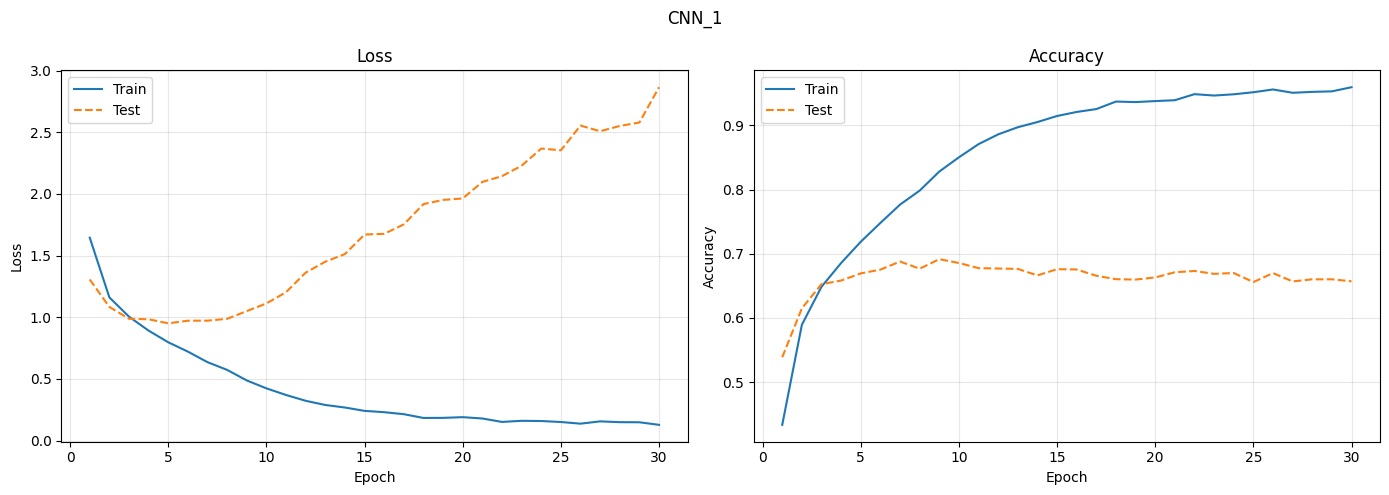

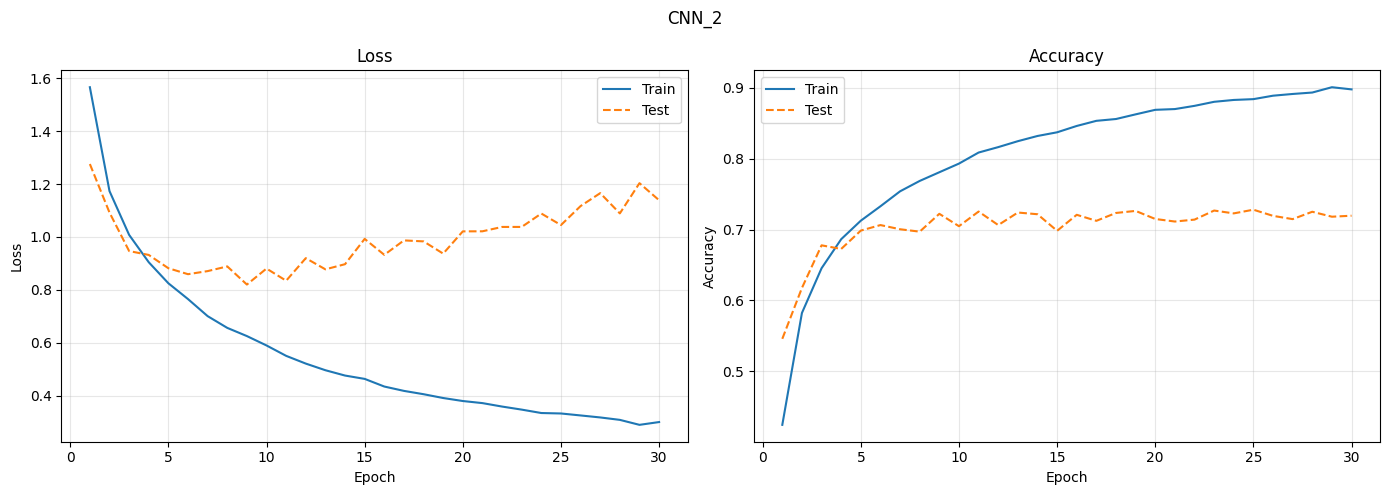

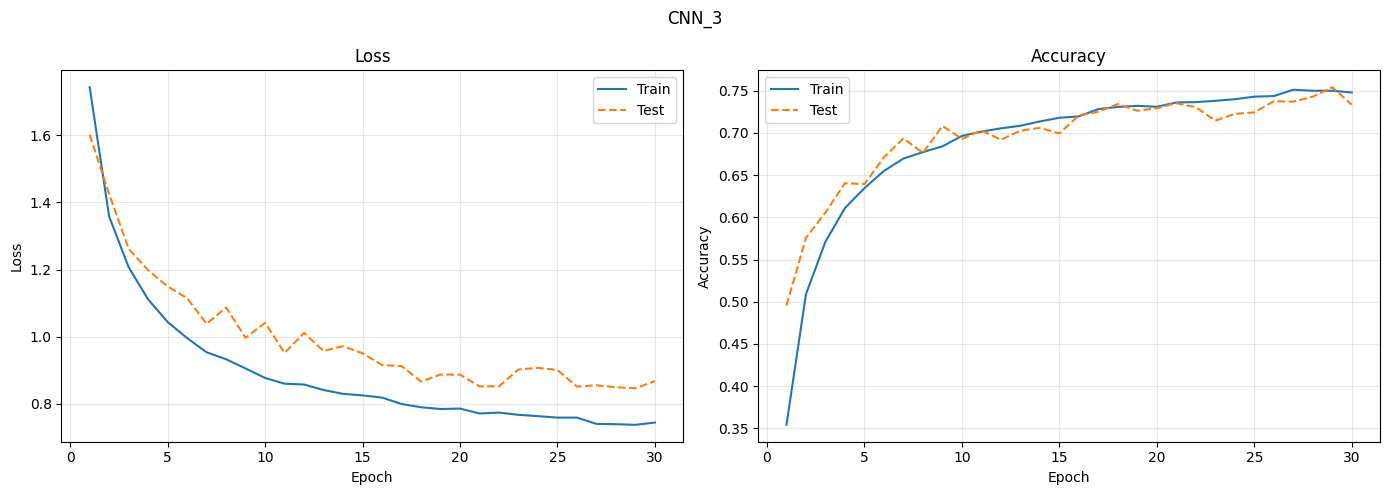

In [13]:
def plot_learning_curves(histories):
    for name, hist in histories.items():
        epochs = range(1, len(hist["train_loss"]) + 1)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(name)

        ax1.plot(epochs, hist["train_loss"], label="Train")
        ax1.plot(epochs, hist["test_loss"], linestyle="--", label="Test")
        ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
        ax1.legend(); ax1.grid(True, alpha=0.3)

        ax2.plot(epochs, hist["train_acc"], label="Train")
        ax2.plot(epochs, hist["test_acc"], linestyle="--", label="Test")
        ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
        ax2.legend(); ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

plot_learning_curves(histories)

## Testing with custom input

Finally let's test the models with some images I found on the internet. We can see that our best model gets all of them right (even the cats impostor one xD)

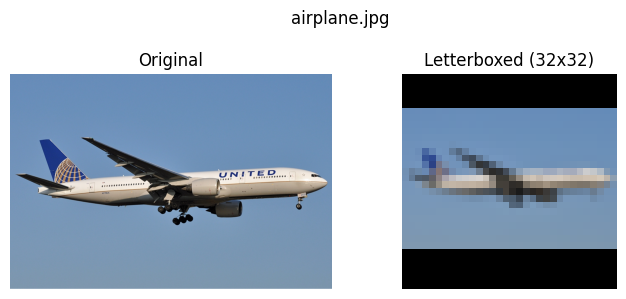

Image: airplane.jpg
CNN_1: airplane
CNN_2: airplane
CNN_3: airplane


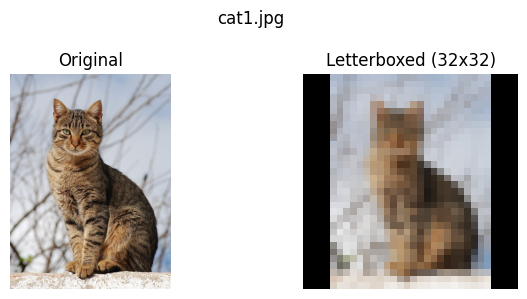

Image: cat1.jpg
CNN_1: cat
CNN_2: cat
CNN_3: cat


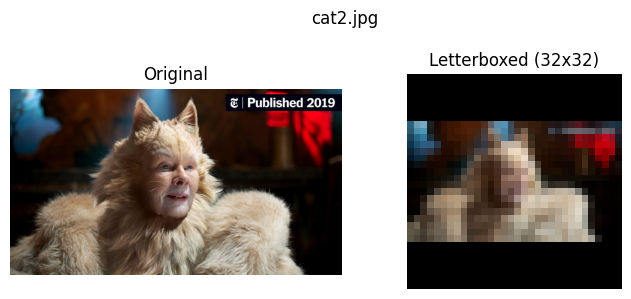

Image: cat2.jpg
CNN_1: automobile
CNN_2: dog
CNN_3: cat


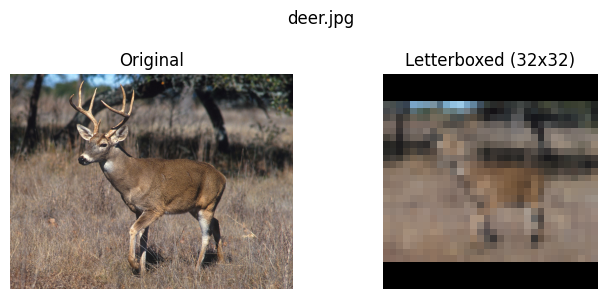

Image: deer.jpg
CNN_1: frog
CNN_2: deer
CNN_3: deer


In [14]:
import os
from PIL import Image

test_images_dir = "data/cifar-10-test"
image_paths = sorted([
    os.path.join(test_images_dir, f)
    for f in os.listdir(test_images_dir)
])

# Used AI help for image conversion since images are not square
def letterbox_to_32(img, fill=(0, 0, 0)):
    w, h = img.size
    scale = 32.0 / max(w, h)
    new_w, new_h = max(1, int(round(w * scale))), max(1, int(round(h * scale)))
    canvas = Image.new("RGB", (32, 32), fill)
    canvas.paste(img.resize((new_w, new_h), Image.BILINEAR), ((32 - new_w) // 2, (32 - new_h) // 2))
    return canvas

for m in trained_models.values():
    m.to(device).eval()

for img_path in image_paths[:10]:
    original_img = Image.open(img_path).convert("RGB")
    modified_img = letterbox_to_32(original_img)

    x = transforms.PILToTensor()(modified_img).unsqueeze(0).to(device=device, dtype=torch.float32)

    with torch.no_grad():
        preds = {name: classes[int(m(x).argmax(dim=1))] for name, m in trained_models.items()}

    fig, axs = plt.subplots(1, 2, figsize=(7, 3))
    axs[0].imshow(original_img); axs[0].set_title("Original"); axs[0].axis("off")
    axs[1].imshow(modified_img); axs[1].set_title("Letterboxed (32x32)"); axs[1].axis("off")
    plt.suptitle(os.path.basename(img_path))
    plt.tight_layout(); plt.show()

    print(f"Image: {os.path.basename(img_path)}")
    for name, label in preds.items():
        print(f"{name}: {label}")

## Conclusion

In this activity we tackled a much more complex task of classifing colored images without the subjects being isolated in the image. Particularly I wnated to test weather the effetiveness of dropout. As we saw in the results, consistent dropout had a major impact on preventing overfitting and thus upping the test accuracy. I think that this is because the images vary quite a lot, a certain image of a cat can look very different to another, even though they're both cats; so learning specific patterns isn't that useful. Learning the overall outline is what's going to help the model in this case.